# 1. Import Visualization Libraries
Import pandas, matplotlib.pyplot, and seaborn for data manipulation and visualization.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# 2. Load and Preprocess Experiment Data
Load 'deit_experiment_results2.csv' and calculate Accuracy Drop.

In [2]:
# Load results
try:
    df = pd.read_csv("experiment_results.csv")
except FileNotFoundError:
    # Fallback to results.csv if name differs
    df = pd.read_csv("experiment_results.csv")

# Calculate metrics
df['accuracy_drop'] = df['accuracy'] - df['baseline_accuracy']
df['relative_accuracy_drop'] = (df['accuracy'] - df['baseline_accuracy']) / df['baseline_accuracy'] * 100
# remove duplicate
df = df.drop_duplicates(subset=['model_name', 'layer', 'hook'])
print(f"Loaded {len(df)} rows across {df['model_name'].nunique()} models.")
df.head()

Loaded 576 rows across 8 models.


,model_name,repo,imagenet_top1,imagenet_top5,params,layer,hook,accuracy,baseline_accuracy,accuracy_drop,relative_accuracy_drop
0,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,0,skip_layer_atten,53.22,66.8,-13.58,-20.329341
1,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,0,skip_layer_attention_residual,0.10,66.8,-66.70,-99.850299
2,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,0,skip_layer_ffn,0.49,66.8,-66.31,-99.266467
3,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,0,skip_layer_ffn_residual,0.49,66.8,-66.31,-99.266467
4,DeiT-tiny,facebook/deit-tiny-patch16-224,72.2,91.1,5M,0,skip_layer_ffn_residual_no_residual_attention,0.00,66.8,-66.80,-100.000000


In [3]:
df['model_name'].unique()

array(['DeiT-tiny', 'DeiT-small', 'DeiT-base', 'DeiT-tiny distilled',
       'DeiT-small distilled', 'DeiT-base distilled', 'DeiT-base 384',
       'DeiT-base distilled 384'], dtype=object)

# 3. Visualize Accuracy Degradation by Layer and Hook Type
Identify critical layers by plotting accuracy vs layer for each model.

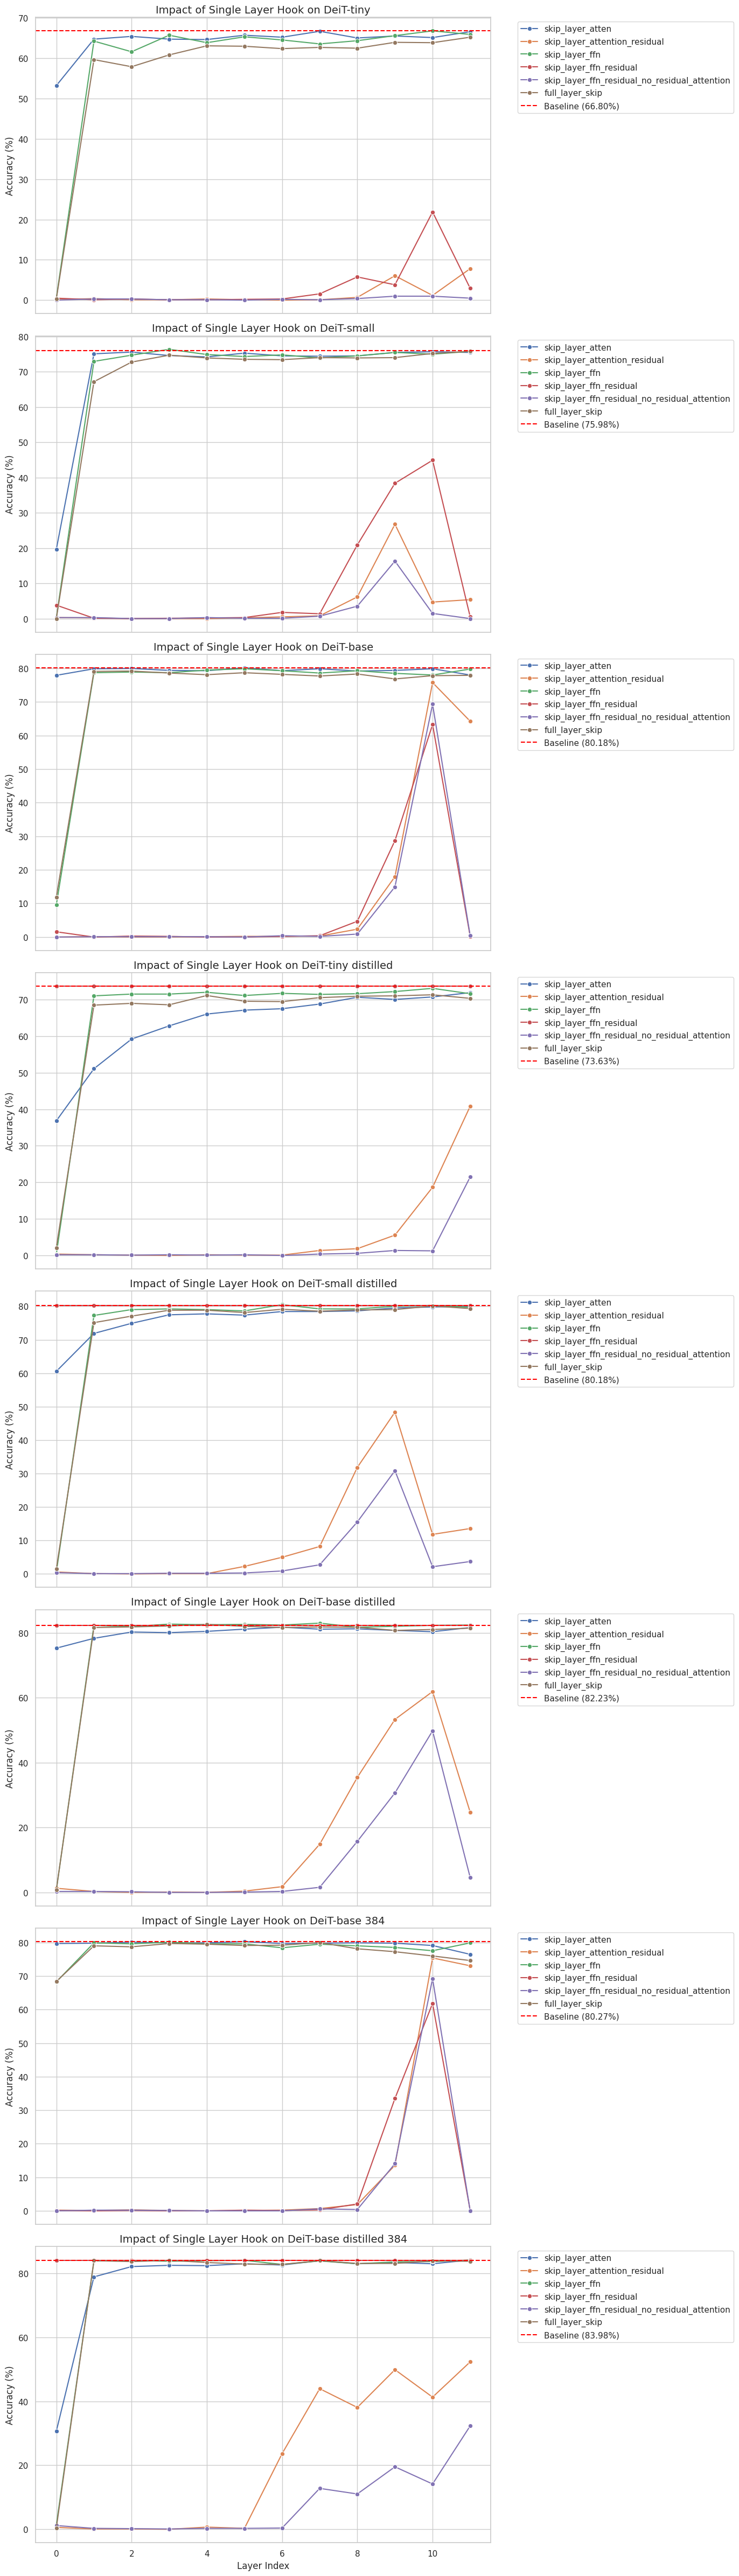

In [4]:
models = df['model_name'].unique()
num_models = len(models)

fig, axes = plt.subplots(num_models, 1, figsize=(14, 6 * num_models), sharex=True)
if num_models == 1: axes = [axes]

for i, model in enumerate(models):
    model_df = df[df['model_name'] == model]
    sns.lineplot(data=model_df, x='layer', y='accuracy', hue='hook', marker='o', ax=axes[i])
    
    # Baseline line
    baseline_acc = model_df['baseline_accuracy'].iloc[0]
    axes[i].axhline(baseline_acc, color='red', linestyle='--', label=f'Baseline ({baseline_acc:.2f}%)')
    
    axes[i].set_title(f"Impact of Single Layer Hook on {model}", fontsize=14)
    axes[i].set_ylabel("Accuracy (%)")
    axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel("Layer Index")
plt.tight_layout()
plt.show()

# 4. Compare Performance Across Model Variants
Comparing the average response to each intervention across different models.

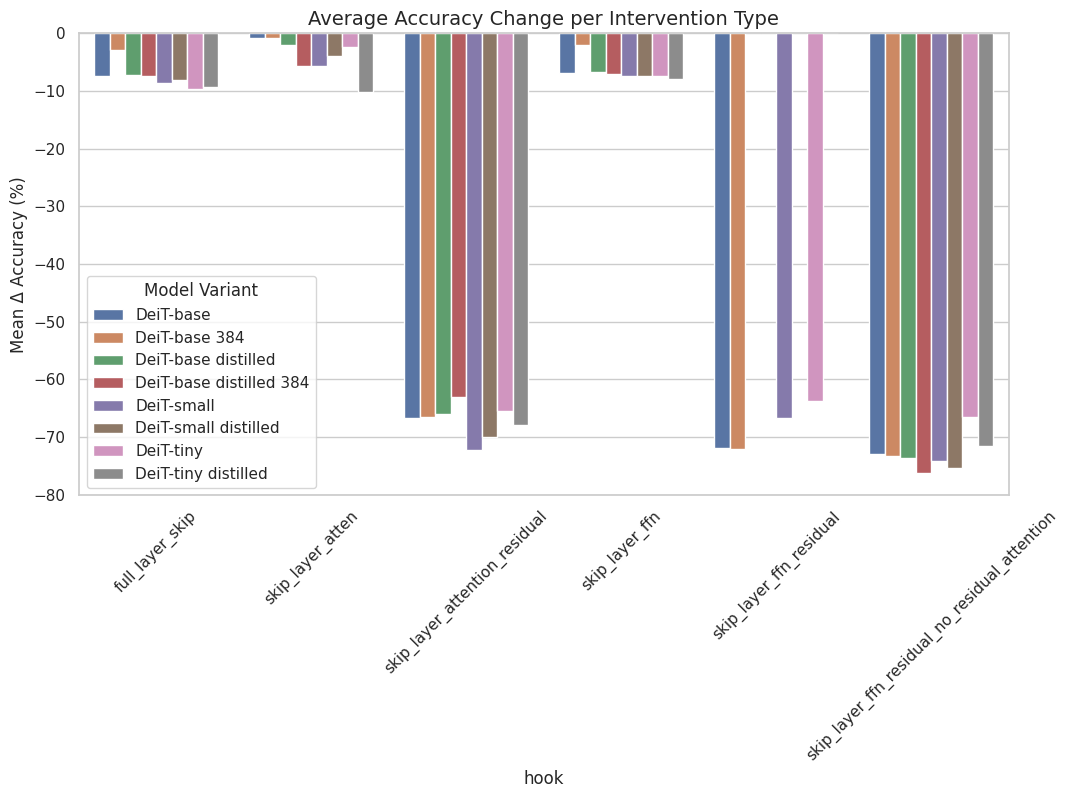

In [5]:
# Average drop per hook type and model
avg_drop = df.groupby(['model_name', 'hook'])['accuracy_drop'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_drop, x='hook', y='accuracy_drop', hue='model_name')
plt.title("Average Accuracy Change per Intervention Type", fontsize=14)
plt.ylabel("Mean Δ Accuracy (%)")
plt.xticks(rotation=45)
plt.legend(title="Model Variant")
plt.show()

# 5. Heatmap Analysis of Layer Sensitivity
Visualize the sensitivity landscape (Accuracy Drop) across layers and hook types.

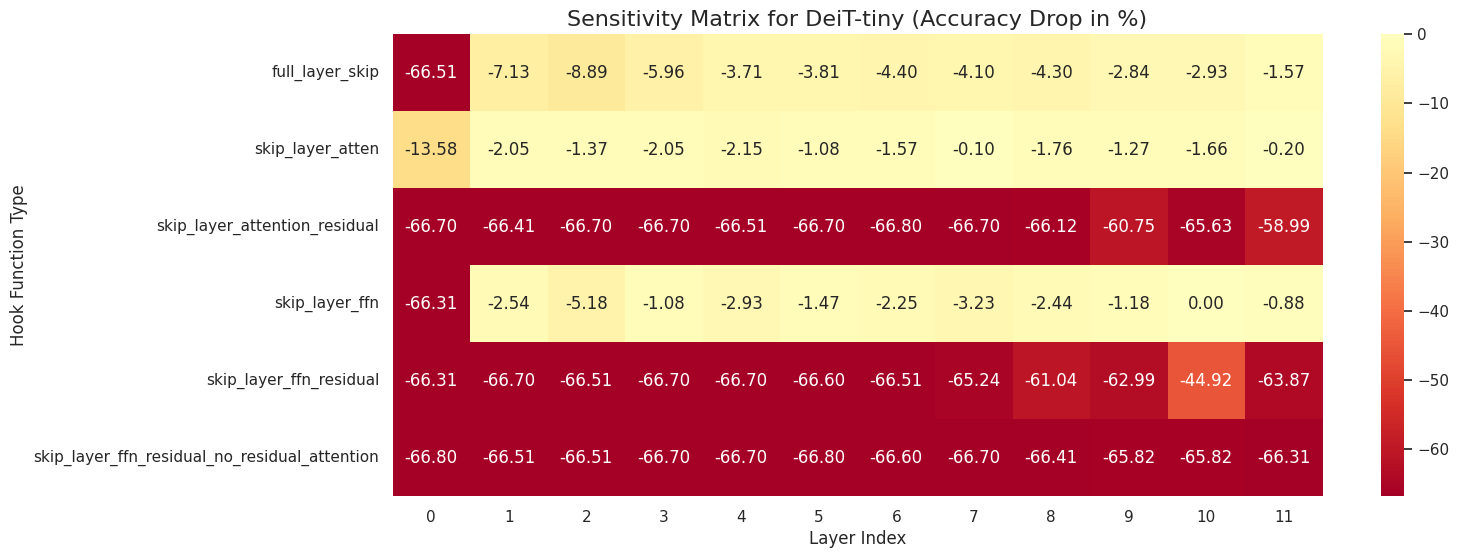

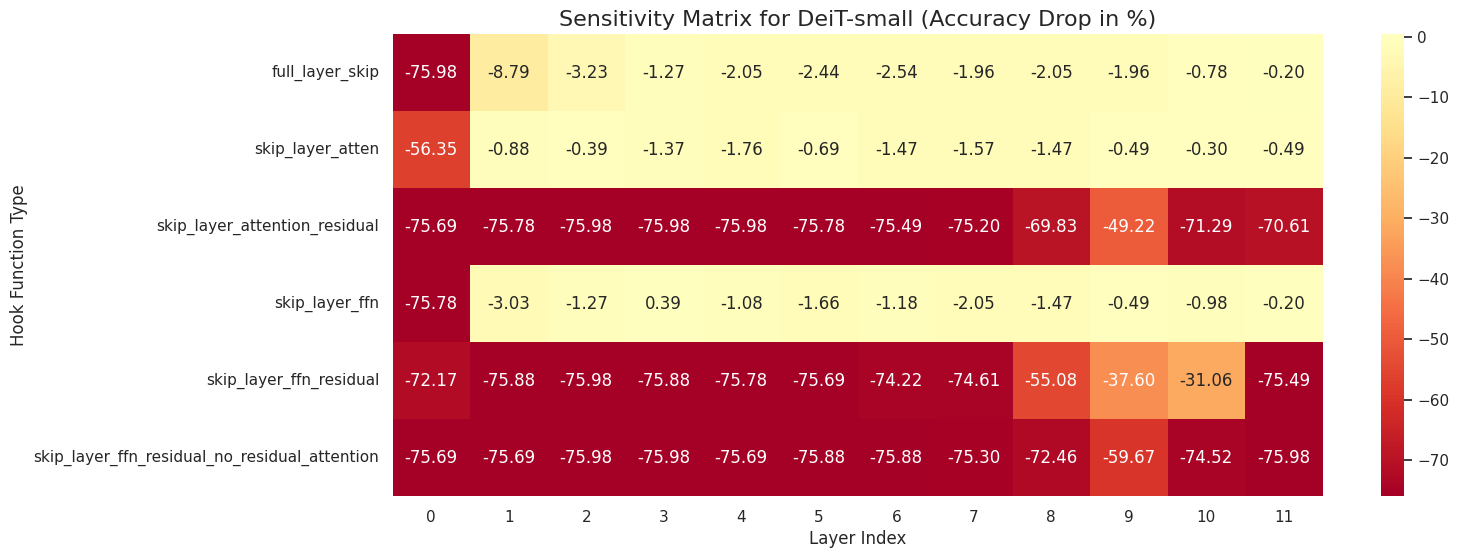

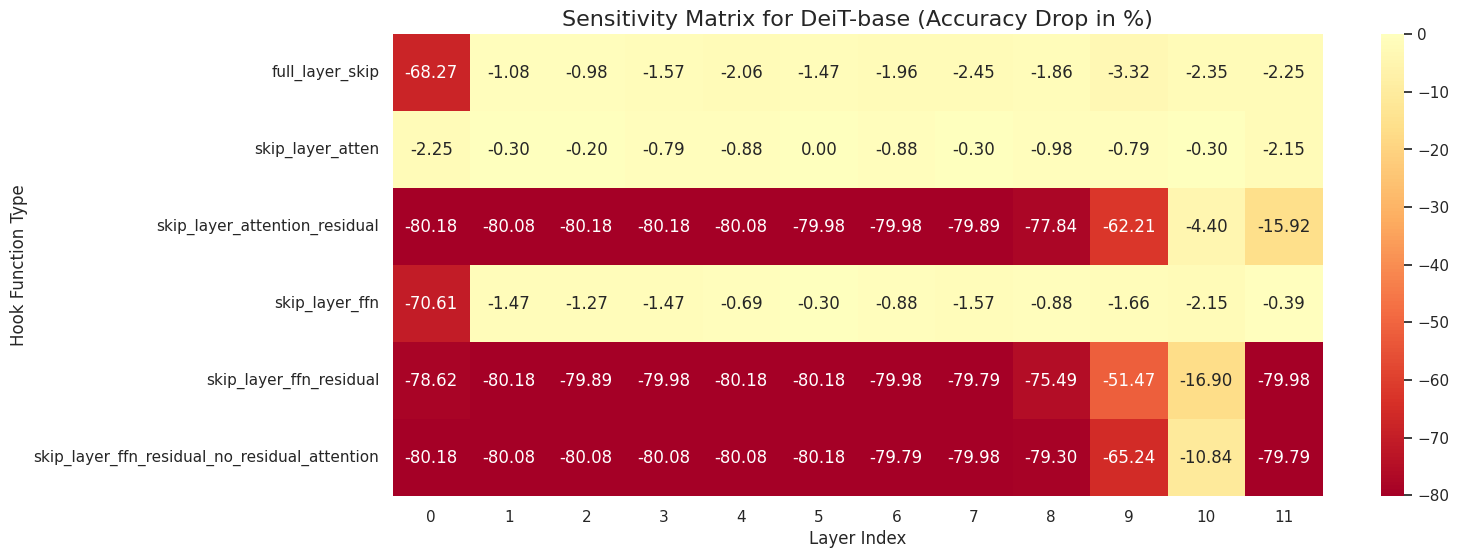

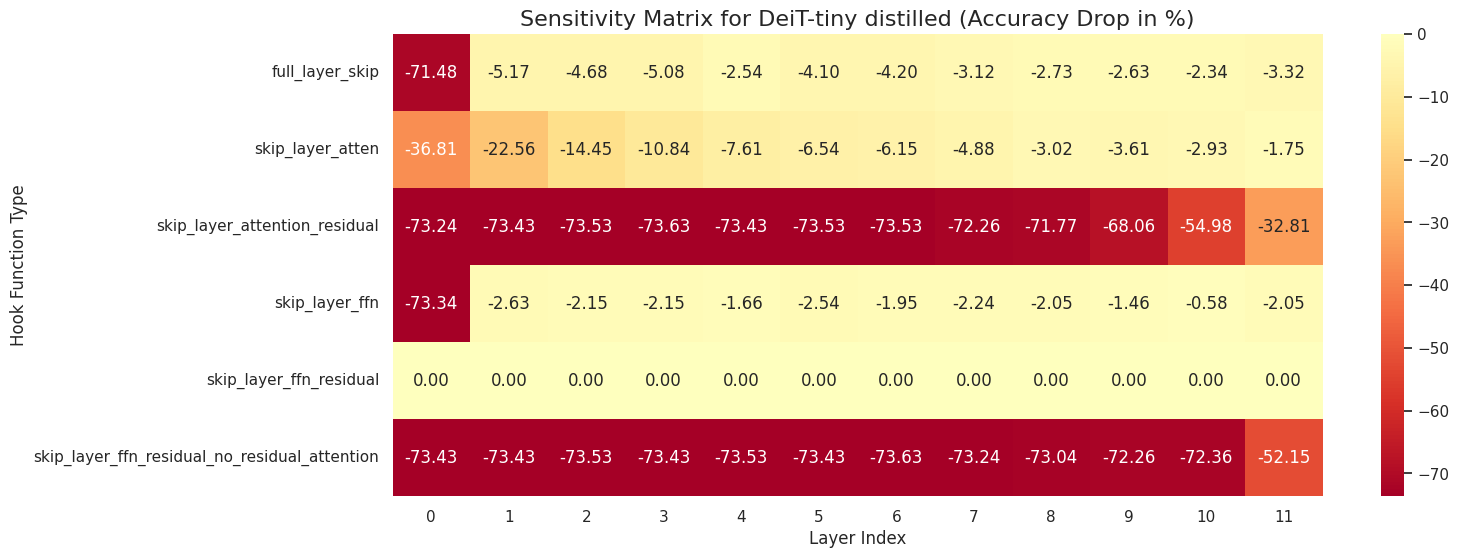

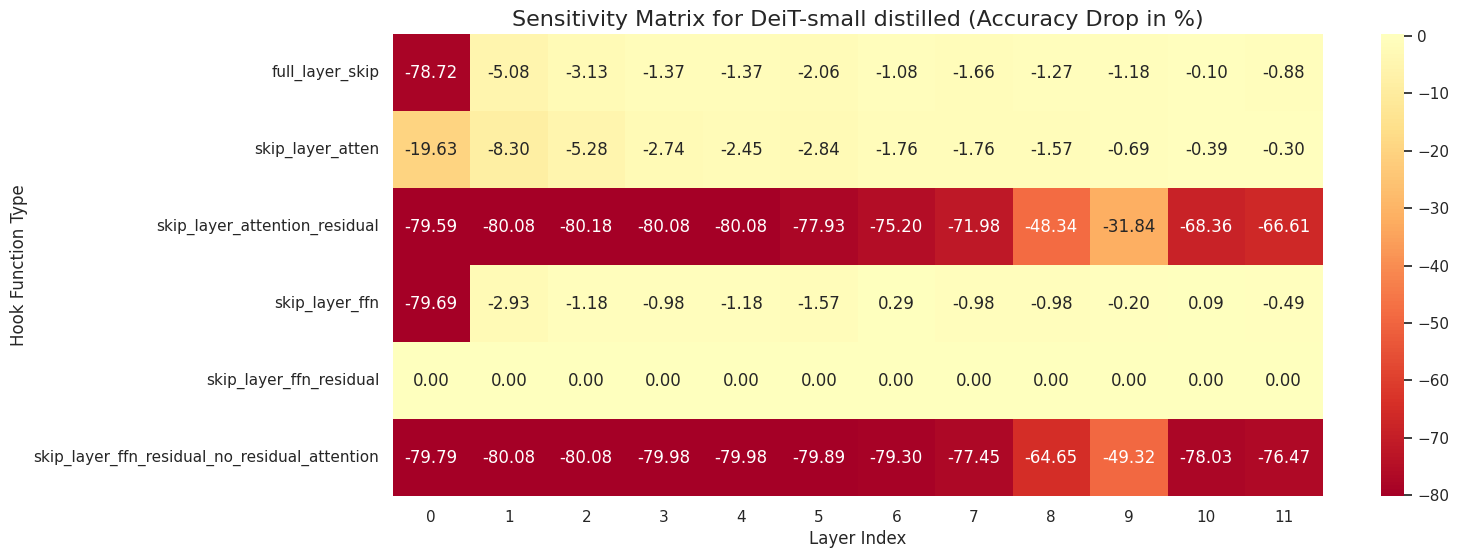

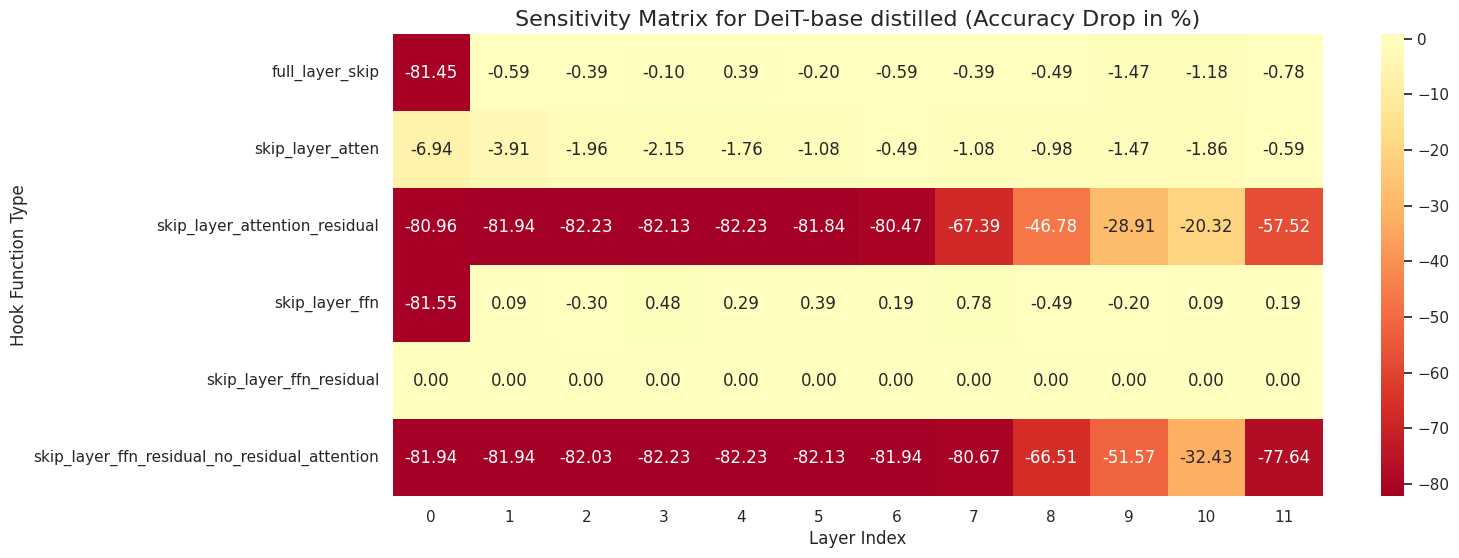

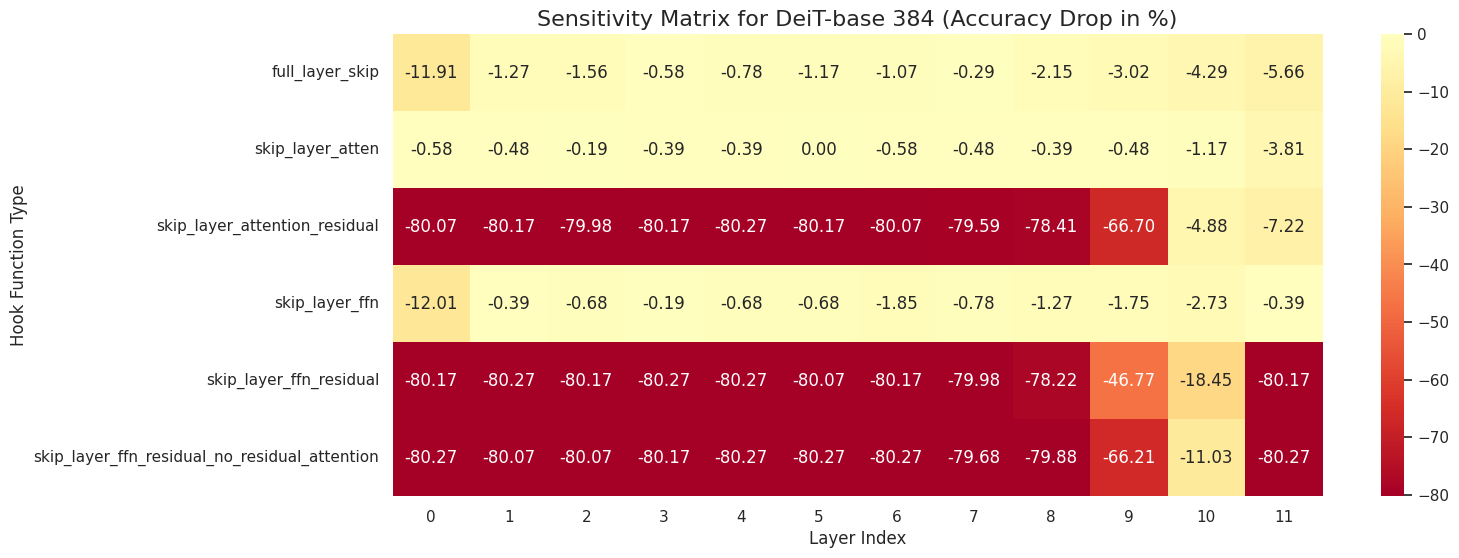

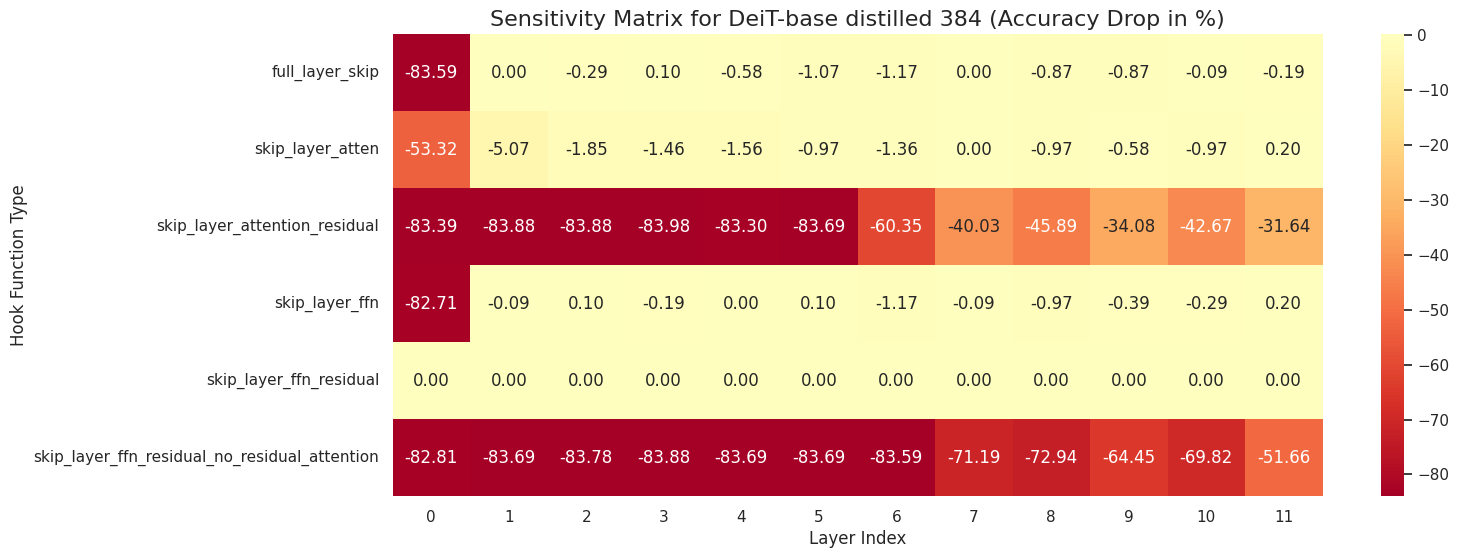

In [6]:
for model in models:
    model_df = df[df['model_name'] == model]
    
    # Pivot for heatmap
    pivot_df = model_df.pivot(index='hook', columns='layer', values='accuracy_drop')
    
    plt.figure(figsize=(15, 6))
    sns.heatmap(pivot_df, annot=True, cmap='RdYlGn', fmt='.2f', center=0)
    plt.title(f"Sensitivity Matrix for {model} (Accuracy Drop in %)", fontsize=16)
    plt.xlabel("Layer Index")
    plt.ylabel("Hook Function Type")
    plt.show()

# 6. Aggregated Analysis and General Patterns
Explore how architectural properties (Size, Distillation) correlate with layer utilization and robustness.

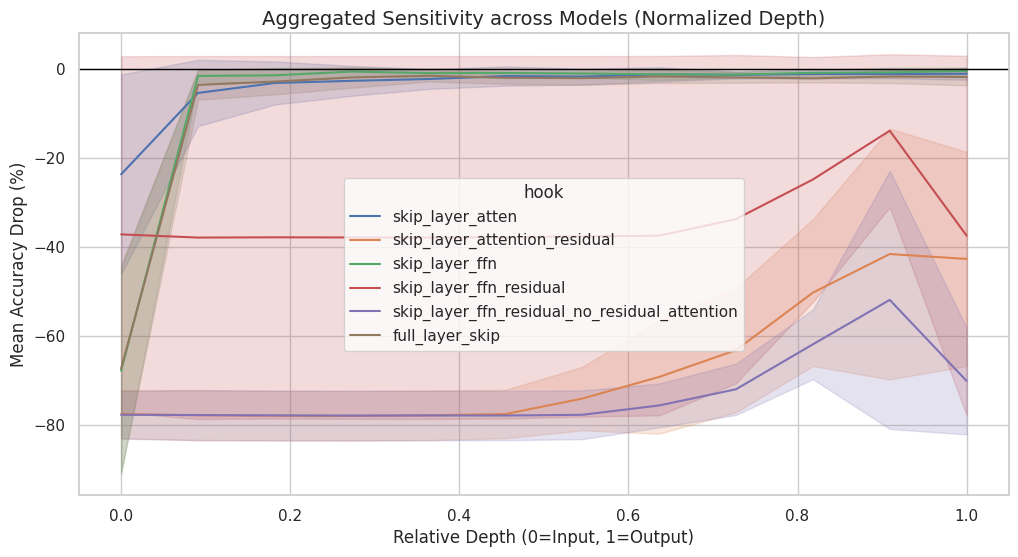

In [7]:
# 6.1 Sensitivity vs Relative Depth (Aggregated)
# This handles models with different depths by normalizing layer index

df['relative_depth'] = df.groupby('model_name')['layer'].transform(lambda x: x / (x.max()))
# rmeove rows with skip_layer_ffn_residual_no_residual_attention hook
#df = df[~df['hook'].isin(['skip_layer_ffn_residual_no_residual_attention', "skip_layer_ffn_residual"])]
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='relative_depth', y='accuracy_drop', hue='hook', errorbar='sd')
plt.title("Aggregated Sensitivity across Models (Normalized Depth)", fontsize=14)
plt.xlabel("Relative Depth (0=Input, 1=Output)")
plt.ylabel("Mean Accuracy Drop (%)")
plt.axhline(0, color='black', linewidth=1)
plt.show()



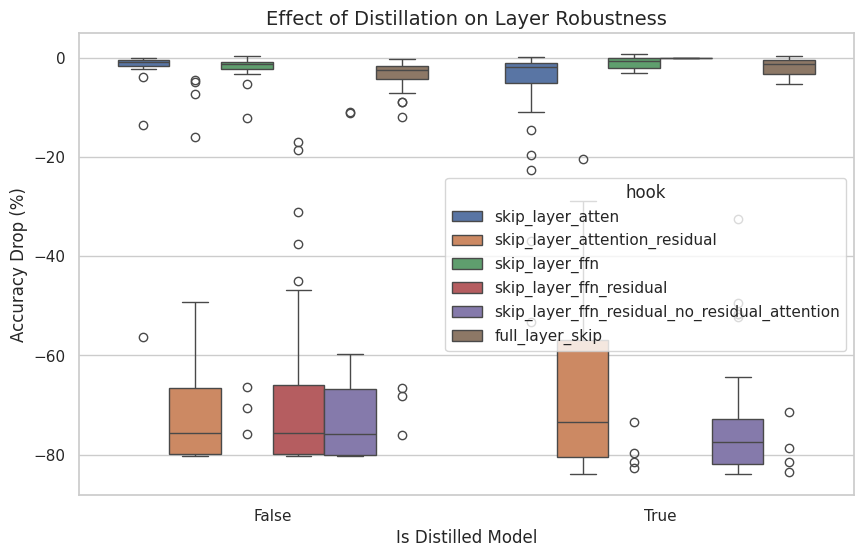

In [8]:
# 6.2 Distillation Impact
df['is_distilled'] = df['model_name'].str.contains('distilled')

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_distilled', y='accuracy_drop', hue='hook')
plt.title("Effect of Distillation on Layer Robustness", fontsize=14)
plt.ylabel("Accuracy Drop (%)")
plt.xlabel("Is Distilled Model")
plt.show()


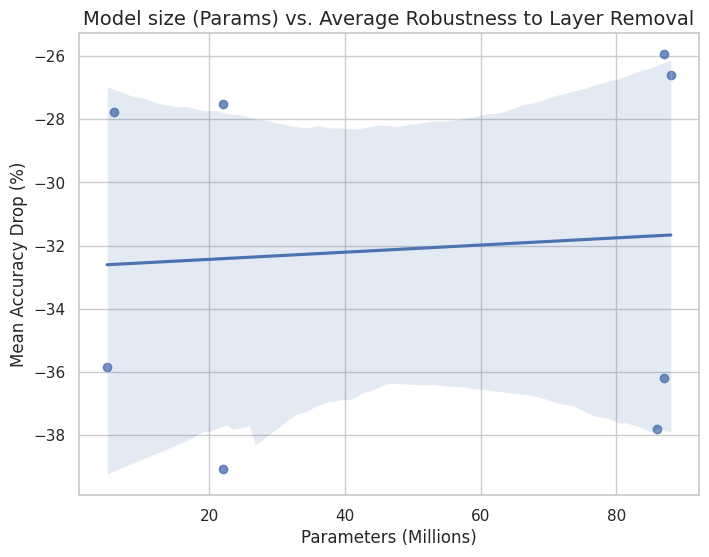

In [9]:

# 6.3 Capacity vs Robustness Pattern
# Extract parameter count as numeric
df['params_val'] = df['params'].str.replace('M', '').astype(float)
robustness = df.groupby(['model_name', 'params_val'])['accuracy_drop'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.regplot(data=robustness, x='params_val', y='accuracy_drop')
plt.title("Model size (Params) vs. Average Robustness to Layer Removal", fontsize=14)
plt.xlabel("Parameters (Millions)")
plt.ylabel("Mean Accuracy Drop (%)")
plt.show()

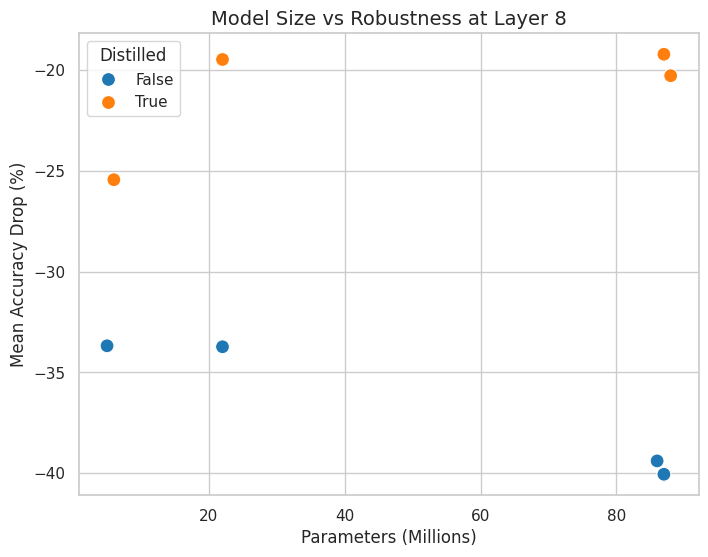

,model_name,params_val,accuracy_drop,is_distilled
6,DeiT-tiny,5.0,-33.678333,False
7,DeiT-tiny distilled,6.0,-25.435000,True
4,DeiT-small,22.0,-33.726667,False
5,DeiT-small distilled,22.0,-19.468333,True
0,DeiT-base,86.0,-39.391667,False
1,DeiT-base 384,87.0,-40.053333,False
2,DeiT-base distilled,87.0,-19.208333,True
3,DeiT-base distilled 384,88.0,-20.273333,True


In [19]:
# 6.3 Capacity vs Robustness Pattern (Layer 0 only)
layer_idx = 8

robustness_layer0 = (
    df[df["layer"] == layer_idx]
    .groupby(["model_name", "params_val"], as_index=False)["accuracy_drop"]
    .mean()
)

# Add distilled flag for coloring
robustness_layer0["is_distilled"] = robustness_layer0["model_name"].str.contains("distilled")

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=robustness_layer0,
    x="params_val",
    y="accuracy_drop",
    hue="is_distilled",
    palette={False: "#1f77b4", True: "#ff7f0e"},
    s=100
)
plt.title(f"Model Size vs Robustness at Layer {layer_idx}", fontsize=14)
plt.xlabel("Parameters (Millions)")
plt.ylabel("Mean Accuracy Drop (%)")
plt.legend(title="Distilled")
plt.show()

robustness_layer0.sort_values("params_val")